In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy
from itertools import product

# loading the required datasets
dataset1 = np.load('/content/drive/MyDrive/hw2_material/kmeans/dataset1.npy')
dataset2 = np.load('/content/drive/MyDrive/hw2_material/kmeans/dataset2.npy')
dataset3 = np.load('/content/drive/MyDrive/hw2_material/kmeans/dataset3.npy')
dataset4 = np.load('/content/drive/MyDrive/hw2_material/kmeans/dataset4.npy')

In [ ]:
print(dataset1.shape)

(7482, 2)


In [ ]:
# a system where we restart the clustering with the same k value but different
# initializations.

# for each dataset -> for k in [1,10] -> restart 10 times

# plotting : x-axis k values, y-axis objective function
# after finding the best k value cluster the dataset
# show the clusters with different colors

# 2 plots for each dataset:
# 1 - k vs objective function (get best k value elbow method)
# 2 - colorization of dataset clusters with best k value

In [ ]:
def initialize_centroids(points, k):
    """returns k centroids from the initial points"""
    centroids = points.copy()
    np.random.shuffle(centroids)
    return centroids[:k]

def euclidean(point_a, point_b):
    return np.linalg.norm(point_a - point_b)

def assign_clusters(data, cluster_centers):
    """
    Assigns every data point to its closest (in terms of Euclidean distance) cluster center.
    :param data: An (N, D) shaped numpy array where N is the number of examples
    and D is the dimension of the data
    :param cluster_centers: A (K, D) shaped numpy array where K is the number of clusters
    and D is the dimension of the data
    :return: An (N, ) shaped numpy array. At its index i, the index of the closest center
    resides to the ith data point.
    """
    result_array = []

    for example in data:
        i = 0
        min_dist = 999999
        correct_index = None
        for cluster in cluster_centers:
            dist = euclidean(example, cluster)
            if dist < min_dist:
                min_dist = dist
                correct_index = i
            i+=1
        result_array.append(correct_index)

    return np.array(result_array)
    # res_array = np.array([])
    # combos = product(data,cluster_centers)
    # prod = len(cluster_centers)
    # distances = [np.linalg.norm(dat - clu) for dat,clu in combos ]

    # min_dists = min(np.linalg.norm(data_elem - clust_elem) for data_elem,clust_elem in product(data,cluster_centers))

def calc_new_center(data):
    x_sum = 0
    y_sum = 0
    i = 0
    for x in data:
        x_sum += x[0]
        y_sum += x[1]
        i += 1
    return [x_sum/i, y_sum/i]


def calculate_cluster_centers(data, assignments, cluster_centers, k):
    """
    Calculates cluster_centers such that their squared Euclidean distance to the data assigned to
    them will be lowest.
    If none of the data points belongs to some cluster center, then assign it to its previous value.
    :param data: An (N, D) shaped numpy array where N is the number of examples
    and D is the dimension of the data
    :param assignments: An (N, ) shaped numpy array with integers inside. They represent the cluster index
    every data assigned to.
    :param cluster_centers: A (K, D) shaped numpy array where K is the number of clusters
    and D is the dimension of the data
    :param k: Number of clusters
    :return: A (K, D) shaped numpy array that contains the newly calculated cluster centers.
    """
    # for a cluster, get all data thats assigned to a cluster
    # sort based on assignments -> 0,2,1,2,0 -> 0,0,1,2,2
    new_data = []
    data = data.tolist()
    assignments = assignments.tolist()
    cluster_centers = cluster_centers.tolist()
    for i in range(len(assignments)):
        new_data.append([data[i],assignments[i]])

    new_data = sorted(new_data, key=lambda x: x[1])

    values = set(map(lambda x:x[1], new_data))
    new_data = [[y[0] for y in new_data if y[1]==x] for x in values]
    result_array = []

    for group in new_data:
        new_center = calc_new_center(group)
        result_array.append(new_center)

    for i in range(k):
        if i not in assignments:
            result_array.insert(i, cluster_centers[i])

    return np.array(result_array)


def kmeans(data, initial_cluster_centers):
    """
    Applies k-means algorithm.
    :param data: An (N, D) shaped numpy array where N is the number of examples
    and D is the dimension of the data
    :param initial_cluster_centers: A (K, D) shaped numpy array where K is the number of clusters
    and D is the dimension of the data
    :return: cluster_centers, objective_function
    cluster_center.shape is (K, D).
    objective function is a float. It is calculated by summing the squared euclidean distance between
    data points and their cluster centers.
    """
    k = len(initial_cluster_centers)
    assignments = assign_clusters(data, initial_cluster_centers)
    cluster_centers = calculate_cluster_centers(data, assignments, initial_cluster_centers, k)
    max_iter = 50
    obj_func = 0
    i = 0
    while i < max_iter:
        length = len(assignments)
        arr = np.ones(length*2, dtype=np.int64)
        arr.reshape(length,2)
        assignments_before = copy.deepcopy(arr)
        assignments = assign_clusters(data, cluster_centers)
        cluster_centers = calculate_cluster_centers(data, assignments, cluster_centers, k)
        if(assignments_before == assignments):
            break
        i += 1

    for j in range(len(data)):
        #  summing the squared euclidean distance between data points and their cluster centers.
        cluster = assignments[j]
        obj_func += (euclidean(data[j], cluster_centers[cluster]))**2

    return cluster_centers, obj_func

Restarted!


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:118: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!


Text(0, 0.5, 'Objective Function')

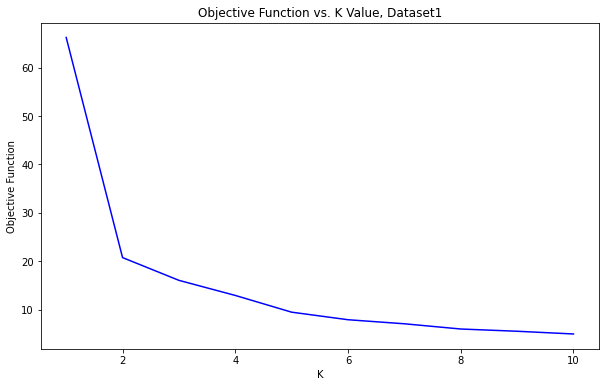

In [ ]:
# dataset1
obj_functions = [0,0,0,0,0,0,0,0,0,0]
current_obj = 0
k = 1
for restart in range(10):
    print("Restarted!")
    while k<11:
        initial_centroids = initialize_centroids(dataset1, k)
        final_centroids, obj_func = kmeans(dataset1, initial_centroids)
        # current_obj += obj_func
        # obj_functions.append(obj_func)
        obj_functions[k-1] = obj_func
        k +=1

obj_functions = [obj_functions[i]/100 for i in range(10)]

plt.figure(figsize=(10,6))
# plt.plot(range(1,k),error_rate,color='blue', linestyle='dashed', marker='o',
#  markerfacecolor='red', markersize=10)
plt.plot(range(1,k), obj_functions, color='blue')
plt.title('Objective Function vs. K Value, Dataset1')
plt.xlabel('K')
plt.ylabel('Objective Function')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:118: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


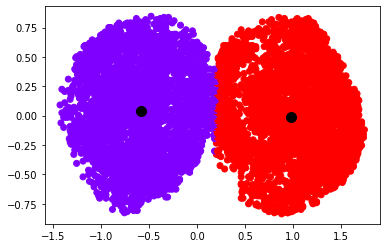

In [ ]:
# testing dataset1 with k =2
initial_centroids = initialize_centroids(dataset1, 2)
final_centroids, obj_func = kmeans(dataset1, initial_centroids)
assignments = assign_clusters(dataset1, final_centroids)

# plt.scatter(dataset1 ,assignments, cmap='rainbow')
plt.scatter(dataset1[:,0],dataset1[:,1], c=assignments, cmap='rainbow')
plt.scatter(final_centroids[:,0], final_centroids[:,1], c ='black', s = 200)

Restarted!


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:118: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!


Text(0, 0.5, 'Objective Function')

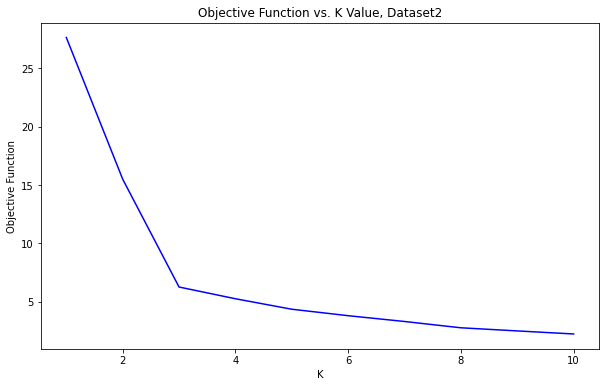

In [ ]:
# dataset 2
obj_functions = [0,0,0,0,0,0,0,0,0,0]
current_obj = 0
k = 1
for restart in range(10):
    print("Restarted!")
    while k<11:
        initial_centroids = initialize_centroids(dataset2, k)
        final_centroids, obj_func = kmeans(dataset2, initial_centroids)
        # current_obj += obj_func
        # obj_functions.append(obj_func)
        obj_functions[k-1] = obj_func
        k +=1

obj_functions = [obj_functions[i]/100 for i in range(10)]

plt.figure(figsize=(10,6))
# plt.plot(range(1,k),error_rate,color='blue', linestyle='dashed', marker='o',
#  markerfacecolor='red', markersize=10)
plt.plot(range(1,k), obj_functions, color='blue')
plt.title('Objective Function vs. K Value, Dataset2')
plt.xlabel('K')
plt.ylabel('Objective Function')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:118: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


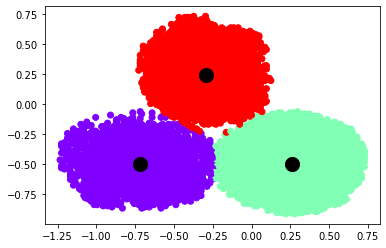

In [ ]:
# testing dataset2 with k =3
initial_centroids = initialize_centroids(dataset2, 3)
final_centroids, obj_func = kmeans(dataset2, initial_centroids)
assignments = assign_clusters(dataset2, final_centroids)

# plt.scatter(dataset1 ,assignments, cmap='rainbow')
plt.scatter(dataset2[:,0],dataset2[:,1], c=assignments, cmap='rainbow')
plt.scatter(final_centroids[:,0], final_centroids[:,1], c ='black', s = 200)

Restarted!


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:118: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!


Text(0, 0.5, 'Objective Function')

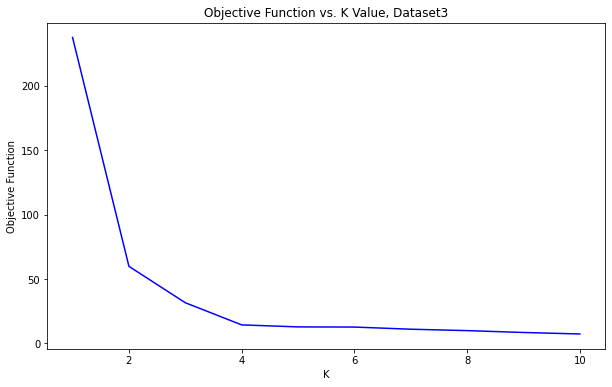

In [ ]:
# dataset 3
obj_functions = [0,0,0,0,0,0,0,0,0,0]
current_obj = 0
k = 1
for restart in range(10):
    print("Restarted!")
    while k<11:
        initial_centroids = initialize_centroids(dataset3, k)
        final_centroids, obj_func = kmeans(dataset3, initial_centroids)
        # current_obj += obj_func
        # obj_functions.append(obj_func)
        obj_functions[k-1] = obj_func
        k +=1

obj_functions = [obj_functions[i]/100 for i in range(10)]

plt.figure(figsize=(10,6))
# plt.plot(range(1,k),error_rate,color='blue', linestyle='dashed', marker='o',
#  markerfacecolor='red', markersize=10)
plt.plot(range(1,k), obj_functions, color='blue')
plt.title('Objective Function vs. K Value, Dataset3')
plt.xlabel('K')
plt.ylabel('Objective Function')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:118: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


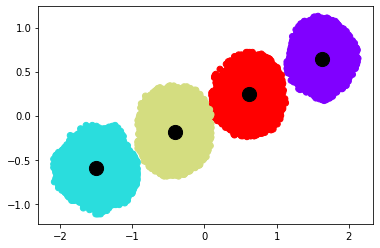

In [ ]:
# testing dataset3 with k = 4
initial_centroids = initialize_centroids(dataset3, 4)
final_centroids, obj_func = kmeans(dataset3, initial_centroids)
assignments = assign_clusters(dataset3, final_centroids)

# plt.scatter(dataset1 ,assignments, cmap='rainbow')
plt.scatter(dataset3[:,0],dataset3[:,1], c=assignments, cmap='rainbow')
plt.scatter(final_centroids[:,0], final_centroids[:,1], c ='black', s = 200)

Restarted!


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:118: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!
Restarted!


Text(0, 0.5, 'Objective Function')

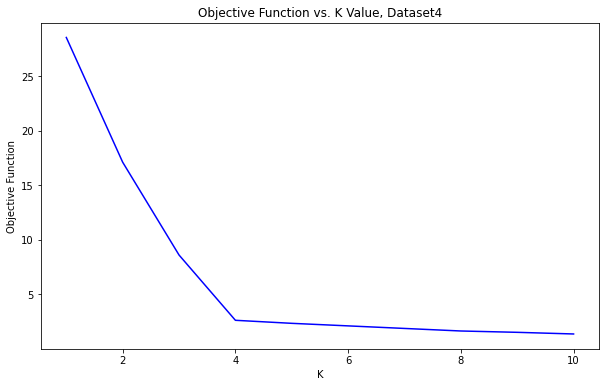

In [ ]:
# dataset 4
obj_functions = [0,0,0,0,0,0,0,0,0,0]
current_obj = 0
k = 1
for restart in range(10):
    print("Restarted!")
    while k<11:
        initial_centroids = initialize_centroids(dataset4, k)
        final_centroids, obj_func = kmeans(dataset4, initial_centroids)
        # current_obj += obj_func
        # obj_functions.append(obj_func)
        obj_functions[k-1] = obj_func
        k +=1

obj_functions = [obj_functions[i]/100 for i in range(10)]

plt.figure(figsize=(10,6))
# plt.plot(range(1,k),error_rate,color='blue', linestyle='dashed', marker='o',
#  markerfacecolor='red', markersize=10)
plt.plot(range(1,k), obj_functions, color='blue')
plt.title('Objective Function vs. K Value, Dataset4')
plt.xlabel('K')
plt.ylabel('Objective Function')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:118: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


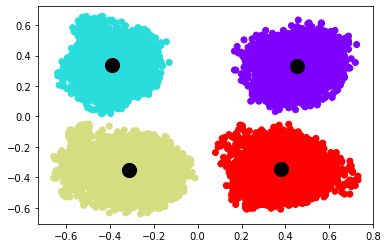

In [ ]:
# testing dataset4 with k = 4
initial_centroids = initialize_centroids(dataset4, 4)
final_centroids, obj_func = kmeans(dataset4, initial_centroids)
assignments = assign_clusters(dataset4, final_centroids)

# plt.scatter(dataset1 ,assignments, cmap='rainbow')
plt.scatter(dataset4[:,0],dataset4[:,1], c=assignments, cmap='rainbow')
plt.scatter(final_centroids[:,0], final_centroids[:,1], c ='black', s = 200)